In [72]:
import json
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from core.normalizer import compute_wallmid1, compute_wallmid2, compute_wallmid3, compute_wallmid_ma

In [73]:
IPR = "INTARIAN_PEPPER_ROOT"
ACO = "ASH_COATED_OSMIUM"

#excel data
df_day1 = pd.read_csv("/Users/alexoddsh/prosperity/backend/backtester/resources-4/round1/prices_round_1_day_-2.csv", sep=";")
df_day2 = pd.read_csv("/Users/alexoddsh/prosperity/backend/backtester/resources-4/round1/prices_round_1_day_-1.csv",  sep=";")
df_day3 = pd.read_csv("/Users/alexoddsh/prosperity/backend/backtester/resources-4/round1/prices_round_1_day_0.csv",  sep=";")

df_day1_ipr = df_day1[df_day1["product"] == IPR]
df_day2_ipr = df_day2[df_day2["product"] == IPR]
df_day3_ipr = df_day3[df_day3["product"] == IPR]

df_day2_ipr["timestamp"] = df_day2_ipr["timestamp"] + 1000000 
df_day3_ipr["timestamp"] = df_day3_ipr["timestamp"] + 2000000

df_day1_ipr["mid_price"] = df_day1_ipr["mid_price"].ffill()
df_day2_ipr["mid_price"] = df_day2_ipr["mid_price"].ffill()
df_day3_ipr["mid_price"] = df_day3_ipr["mid_price"].ffill()

df_day1_aco = df_day1[df_day1["product"] == ACO]
df_day2_aco = df_day2[df_day2["product"] == ACO]
df_day3_aco = df_day3[df_day3["product"] == ACO]

df_day2_aco["timestamp"] = df_day2_aco["timestamp"] + 1000000 
df_day3_aco["timestamp"] = df_day3_aco["timestamp"] + 2000000
df_day1_aco["mid_price"] = df_day1_aco["mid_price"].ffill()
df_day2_aco["mid_price"] = df_day2_aco["mid_price"].ffill()
df_day3_aco["mid_price"] = df_day3_aco["mid_price"].ffill()

df_ipr = pd.concat([df_day1_ipr, df_day2_ipr, df_day3_ipr])
df_ipr["ask_price_1"] = df_ipr["ask_price_1"].ffill() 
df_ipr["bid_price_1"]= df_ipr["bid_price_1"].ffill() 

df_aco = pd.concat([df_day1_aco, df_day2_aco, df_day3_aco])

tf_day1 = pd.read_csv("/Users/alexoddsh/prosperity/backend/backtester/resources-4/round1/trades_round_1_day_-2.csv", sep=";")
tf_day2 = pd.read_csv("/Users/alexoddsh/prosperity/backend/backtester/resources-4/round1/trades_round_1_day_-1.csv",  sep=";")
tf_day3 = pd.read_csv("/Users/alexoddsh/prosperity/backend/backtester/resources-4/round1/trades_round_1_day_0.csv",  sep=";")

tf_day1_ipr = tf_day1[tf_day1["symbol"] == IPR]
tf_day2_ipr = tf_day2[tf_day2["symbol"] == IPR]
tf_day3_ipr = tf_day3[tf_day3["symbol"] == IPR]

tf_day2_ipr["timestamp"] = tf_day2_ipr["timestamp"] + 1000000
tf_day3_ipr["timestamp"] = tf_day3_ipr["timestamp"] + 2000000

tf_day1_aco = tf_day1[tf_day1["symbol"] == ACO]
tf_day2_aco = tf_day2[tf_day2["symbol"] == ACO]
tf_day3_aco = tf_day3[tf_day3["symbol"] == ACO]

tf_day2_aco["timestamp"] = tf_day2_aco["timestamp"] + 1000000
tf_day3_aco["timestamp"] = tf_day3_aco["timestamp"] + 2000000

tf_ipr = pd.concat([tf_day1_ipr, tf_day2_ipr, tf_day3_ipr])
tf_aco = pd.concat([tf_day1_aco, tf_day2_aco, tf_day3_aco])

#sim data
log_path=Path("/Users/alexoddsh/prosperity/backend/logs/166184.log")
data = json.loads(log_path.read_text())
ai = data["activitiesLog"]
th = data["tradeHistory"]
ied = data["logs"]

prices = pd.read_csv(io.StringIO(ai), sep=";")
trades = pd.DataFrame(th)

prices["day"] = 1
trades["day"] = 1

sim_df_ipr = prices[prices["product"] == IPR]  
sim_tf_ipr = trades[trades["symbol"] == IPR]
sim_df_ipr["ask_price_1"] = sim_df_ipr["ask_price_1"].ffill()
sim_df_ipr["bid_price_1"] = sim_df_ipr["bid_price_1"].ffill() 

sim_df_aco = prices[prices["product"] == ACO]
sim_tf_aco = trades[trades["symbol"] == ACO]
sim_df_aco["ask_price_1"] = sim_df_aco["ask_price_1"].ffill()
sim_df_aco["bid_price_1"] = sim_df_aco["bid_price_1"].ffill() 



Intercept: 9983.04
Slope: 0.0997


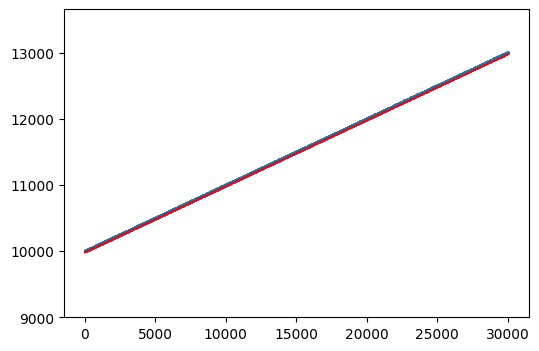

13.039466666666666
79480.0


In [74]:
X = df_ipr["timestamp"].to_numpy()
X = X / 100

X = np.column_stack([np.ones(len(X)), X])
Y = df_ipr["mid_price"]

beta = np.linalg.lstsq(X, Y, rcond=None)[0]

print(f"Intercept: {round(beta[0], 2)}")
print(f"Slope: {round(beta[1], 4)}")

t = np.linspace(0, 30000, 30000)
y = beta[0] + beta[1] * t

fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(X[:, 1], Y, s=1)
ax.plot(t, y , color='red')
ax.set_ylim(bottom=9000)
plt.show()

spread = df_ipr["ask_price_1"] - df_ipr["bid_price_1"]
print(spread.mean())
print(80*(10000*0.1-6.5))

The data is kinda noisy around this line in terms of the mid but imagine instead of the mid we had something more like wallmid, over the course of a day that is essentially a linear function for IPR. So we can model our optimization given that.

What we need to "optimize" is not the question of "is buying at different times better or worse". We would be just as well off. The question is rather do we sacrifice some of the long position. As we see from the regression, over the course of the day the price will essentially increase linearly by 0.0997 per tick, given this linear nature the optimal solutions are either of these:

1. Buy and hold. 80 * 10.000 * 0.1 = 80.000 Profit. The likely however will be a tiny bit lower due to vol and that we cannot fill all in the first timestamp. However also a bit minus since we will need to fill at the ask.  Avg spread is 13. Assuming that FV is at some kind of wallmid similar calc (we should check) then we are buying at circa 6.5 above FV. Real profit is:
-> 80 * (9990 * 0.1 - 6.5) = 79,000 - 79,500 ish.

2. Market make with long position. For simplicity, say that we then have two main variables. a) avg position LONG b) profit per market making vol. Profit becomes more like: 
-> Avg. Pos * (9990*0.1 - 6.5) + Avg.vol MM/timestamp * (10000) * Avg.profit per MM

We ofc need to maximize both. But these then depend on downstream variables. Avg.vol MM/timestamp and Avg.profit per MM is dependent on:
-> Volume Traded (limited by how large we want the avg position LONG to be)
-> How deep inside the spread quotes are/potential skew of bid to maintain LONG

Also the above doesn't even really work because we build the long by USING a skewed MM strat, how would we even separate the two?

Notice how the math gets real complex since volume traded may or may not have a large dependency on how deep inside the spread we quote, most years before it seems that enticing boths to shrink the spread isnt actually that effective, we will fill more opportunistic takers but the majority of fills are by real takers anyways, aka taking the best price, raising it from bid + 1 to bid + 4 for example doesnt seem to increase volume that much, the only added vol is the "opportunistic takers" but these dont contribute that much in PnL terms anyways. 

Now for strat nr.2 there is another mention, should we also apply the normal "taking logic"? aka were we take volume that we believe is profitable? This is taking all profitable bids/asks at t and then hopefully if we keep trading these takes closer to the bid are closed in the next few ticks before price has shifted above. 

This is actually something that would be possible to meaningfully compute a rule for. Since we know the price drift of 0.0997 per t and that FV and Wallmid (need to confirm this) has a very strong correlation then we could implement rule logic that the expected profit of a take at the ask is essentially EDGE - 0.0997 * avg holding ticks. Avg holding ticks could cant however be computed from back data, we would need to instead create some kind of probability model, what is the likelihood to get filled at the ask in the coming ticks for a similar or larger volume but this is hard since normal market making activities are always interfering. 

As I see it, our best options are either go for nr 1 stupid easy but free money maybe lose tiny bit of edge in round 1. Or better do option 2 but instead of trying to form what is likely going to be not a super accurate probability etc model to optimize, we could plug in our option 2 code to the gridtester and simply compute PnLs for 1000s of different rule combos. Slight problem with that is that it needs "constants" to form the rules over the whole trading day but since the trading day is literally just a linear function with some tiny added noise this could be OK. Option 3 try to via theory arrive at the mathematical optimal strat. 




      timestamp     error
1591      79500  1.850586
1588      79400  1.661133
1920      96000  1.640625


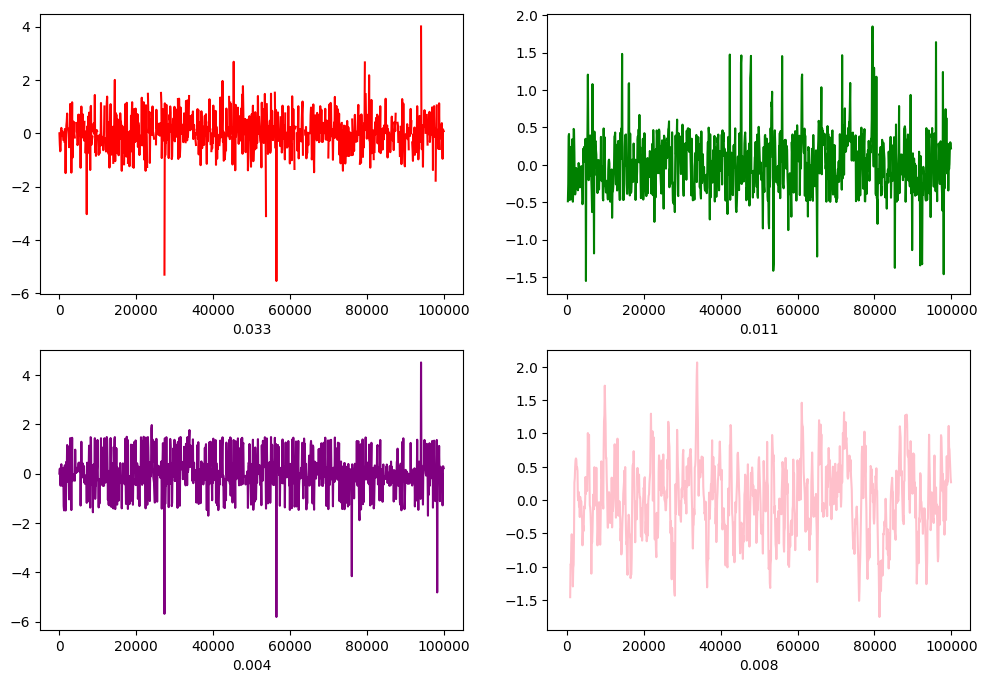

count    998.000000
mean       0.011269
std        0.397433
min       -1.554688
25%       -0.245850
50%       -0.011230
75%        0.265381
max        1.850586
dtype: float64
count    1000.000000
mean        0.003673
std         0.826542
min        -5.814453
25%        -0.367920
50%        -0.017578
75%         0.373047
max         4.510742
dtype: float64
count    992.000000
mean       0.008378
std        0.564565
min       -1.752539
25%       -0.357666
50%        0.004004
75%        0.403711
max        2.065625
dtype: float64


In [75]:
success = compute_wallmid3(ACO, sim_df_aco)
success = compute_wallmid1(ACO, sim_df_aco)
success = compute_wallmid2(ACO, sim_df_aco)

sim_df_aco_copy = sim_df_aco.copy()
sim_df_aco_copy["bid_price_2"] = sim_df_aco_copy["bid_price_2"].ffill()
sim_df_aco_copy["ask_price_2"] = sim_df_aco_copy["ask_price_2"].ffill() 
sim_df_aco_copy["bid_price_3"] = sim_df_aco_copy["bid_price_3"].ffill()
sim_df_aco_copy["ask_price_3"] = sim_df_aco_copy["ask_price_3"].ffill() 


prev = ""
for i in sim_df_aco.index:
    
    has_ask3 = pd.notna(sim_df_aco.loc[i, "ask_price_3"])
    has_bid3 = pd.notna(sim_df_aco.loc[i, "bid_price_3"])
    has_bid2 = pd.notna(sim_df_aco.loc[i, "bid_price_2"])
    has_ask2 = pd.notna(sim_df_aco.loc[i, "ask_price_2"])

    if has_ask3 and not has_bid3:
        sim_df_aco.loc[i, "walllvl2"] = (sim_df_aco.loc[i, "ask_price_3"] + sim_df_aco_copy.loc[i, "bid_price_2"]) / 2
        prev ="3v2"

    elif has_bid3 and not has_ask3:
        sim_df_aco.loc[i, "walllvl2"] = (sim_df_aco_copy.loc[i, "ask_price_2"] + sim_df_aco.loc[i, "bid_price_3"]) / 2
        prev ="2v3"
    
    elif prev=="3v2":
        sim_df_aco.loc[i, "walllvl2"] = (sim_df_aco_copy.loc[i, "ask_price_3"] + sim_df_aco_copy.loc[i, "bid_price_2"]) / 2
        prev="0v0"

    elif prev=="2v3":
        sim_df_aco.loc[i, "walllvl2"] = (sim_df_aco_copy.loc[i, "ask_price_2"] + sim_df_aco_copy.loc[i, "bid_price_3"]) / 2
        prev="0v0"
    
    else:
        sim_df_aco.loc[i, "walllvl2"] = (sim_df_aco_copy.loc[i, "ask_price_2"] + sim_df_aco_copy.loc[i, "bid_price_2"]) / 2
        prev="0v0"

success = compute_wallmid_ma(ACO, sim_df_aco)

if success:
    entry_price = sim_tf_aco.iloc[0]["price"]
    trade_qty = sim_tf_aco.iloc[0]["quantity"]
        
    for i in sim_df_aco.index:
        mid_gap = sim_df_aco.loc[i, "mid_price"] - entry_price
        wall1_gap = sim_df_aco.loc[i, "wallmid1"] - entry_price
        wall2_gap = sim_df_aco.loc[i, "walllvl2"] - entry_price
        wall3_gap = sim_df_aco.loc[i, "wallmid3"] - entry_price
        wallma_gap = sim_df_aco.loc[i, "wallmidsma"] - entry_price
        
        mid_pnl = mid_gap *trade_qty
        wall1_pnl = wall1_gap * trade_qty
        wall2_pnl = wall2_gap * trade_qty
        wall3_pnl = wall3_gap * trade_qty
        wallma_pnl = wallma_gap * trade_qty

        sim_df_aco.loc[i, "mid_pnl"] = mid_pnl
        sim_df_aco.loc[i, "wall1_pnl"] = wall1_pnl
        sim_df_aco.loc[i, "wall2_pnl"] = wall2_pnl
        sim_df_aco.loc[i, "wall3_pnl"] = wall3_pnl
        sim_df_aco.loc[i, "wallma_pnl"] = wallma_pnl

    timestamps = sim_df_aco["timestamp"]
    pnls = sim_df_aco["profit_and_loss"]

    error_mid = (pnls - sim_df_aco["mid_pnl"]) / trade_qty
    error_wall1 = (pnls - sim_df_aco["wall1_pnl"]) / trade_qty
    error_wall2 = (pnls - sim_df_aco["wall2_pnl"]) / trade_qty
    
    top_n = 3 
    worst_idx = error_wall2.abs().nlargest(top_n).index
    print(sim_df_aco.loc[worst_idx, ["timestamp"]].assign(error=error_wall2.loc[worst_idx]))

    error_wall3 = (pnls - sim_df_aco["wall3_pnl"]) / trade_qty
    error_wallma = (pnls - sim_df_aco["wallma_pnl"]) / trade_qty 

    error_mid.iloc[0] = 0
    error_wall1.iloc[0] = 0
    error_wall2.iloc[0] = 0
    error_wall3.iloc[0] = 0
    error_wallma.iloc[0] = 0

    spread = sim_df_aco["ask_price_1"] - sim_df_aco["bid_price_1"]

    fig, ax = plt.subplots(2, 2,figsize=(12,8))

    ax[0, 0].plot(timestamps, error_wall1, color='red')
    ax[0,0].set_xlabel(round(error_wall1.mean(), 3))

    ax[0, 1].plot(timestamps, error_wall2, color='green')
    ax[0,1].set_xlabel(round(error_wall2.mean(), 3))

    ax[1, 0].plot(timestamps, error_wall3, color='purple')
    ax[1,0].set_xlabel(round(error_wall3.mean(), 3))

    ax[1, 1].plot(timestamps, error_wallma, color='pink')
    ax[1,1].set_xlabel(round(error_wallma.mean(), 3))
    
    plt.show()
    print(error_wall2.describe())
    print(error_wall3.describe())
    print(error_wallma.describe())

else:
    print("fuck")

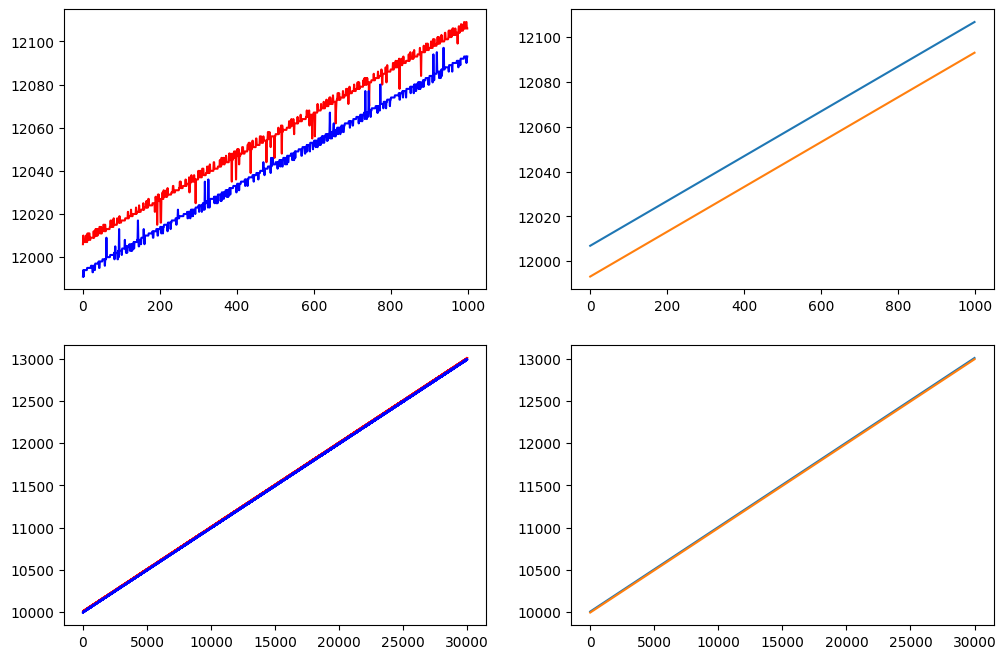

SIM DATA
Intercept Ask: 12006.882483516481
Intercept Bid: 11993.143548451548
Slope Ask: 0.09996699996699968
Slope Bid: 0.09999890199890209

3 DAYS HISTORY
Intercept Ask: 10005.68668519494
Intercept Bid: 9994.246857920298
Slope Ask: 0.10005373166694863
Slope Bid: 0.09994708548594125


In [76]:
#sim data
timestamps = sim_df_ipr["timestamp"].to_numpy() / 100
ask1 = sim_df_ipr["ask_price_1"]
bid1 = sim_df_ipr["bid_price_1"]
X = timestamps
X = np.column_stack([np.ones(len(X)), X])

beta_a = np.linalg.lstsq(X, ask1, rcond=None)[0]
beta_b = np.linalg.lstsq(X, bid1, rcond=None)[0]
y_a = beta_a[0] + beta_a[1] * timestamps
y_b = beta_b[0] + beta_b[1] * timestamps

sim_df_ipr["y_a"] = y_a
sim_df_ipr["y_b"] = y_b
sim_df_ipr["regwall"] = (sim_df_ipr["y_a"] + sim_df_ipr["y_b"]) / 2

#history data
timestamps_h = df_ipr["timestamp"].to_numpy() / 100
ask1_h = df_ipr["ask_price_1"]
bid1_h = df_ipr["bid_price_1"]
XH = timestamps_h
XH = np.column_stack([np.ones(len(XH)), XH])
beta_ah = np.linalg.lstsq(XH, ask1_h, rcond=None)[0]
beta_bh = np.linalg.lstsq(XH, bid1_h, rcond=None)[0]
y_ah = beta_ah[0] + beta_ah[1] * timestamps_h
y_bh = beta_bh[0] + beta_bh[1] * timestamps_h

#figs
fig, ax = plt.subplots(2, 2, figsize=(12,8))

ax[0, 0].plot(timestamps, ask1, color='red')
ax[0, 0].plot(timestamps, bid1, color='blue')
ax[0, 1].plot(timestamps, y_a)
ax[0, 1].plot(timestamps, y_b)

ax[1, 0].plot(timestamps_h, ask1_h, color='red')
ax[1, 0].plot(timestamps_h, bid1_h, color='blue')
ax[1, 1].plot(timestamps_h, y_ah)
ax[1, 1].plot(timestamps_h, y_bh)

plt.show()

print("SIM DATA")
print(f"Intercept Ask: {beta_a[0]}")
print(f"Intercept Bid: {beta_b[0]}")
print(f"Slope Ask: {beta_a[1]}")
print(f"Slope Bid: {beta_b[1]}")
print("")

print("3 DAYS HISTORY")
print(f"Intercept Ask: {beta_ah[0]}")
print(f"Intercept Bid: {beta_bh[0]}")
print(f"Slope Ask: {beta_ah[1]}")
print(f"Slope Bid: {beta_bh[1]}")


count    1000.000000
mean      -49.954487
std        28.877042
min       -99.895984
25%       -74.925242
50%       -49.954500
75%       -24.983758
max         0.000000
dtype: float64


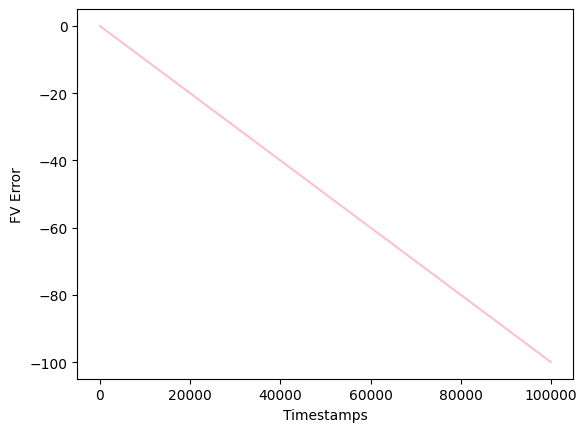

In [77]:
#Potential OP strategy

entry_price = sim_tf_ipr.iloc[0]["price"]
trade_qty = sim_tf_ipr.iloc[0]["quantity"]

for i in sim_df_ipr.index:
    wallmid = sim_df_ipr.loc[i, "regwall"]

    regwall_gap = wallmid - entry_price
    regwall_pnl = regwall_gap *trade_qty

    sim_df_ipr.loc[i, "regwall_pnl"] = regwall_pnl
    
timestamps = sim_df_ipr["timestamp"]
pnls = sim_df_ipr["profit_and_loss"]

error_regwall = (pnls - sim_df_ipr["regwall_pnl"]) / trade_qty
error_regwall.iloc[0] = 0

print(error_regwall.describe())

plt.plot(timestamps, error_regwall, color='pink')
plt.ylabel("FV Error")
plt.xlabel("Timestamps")
plt.show()


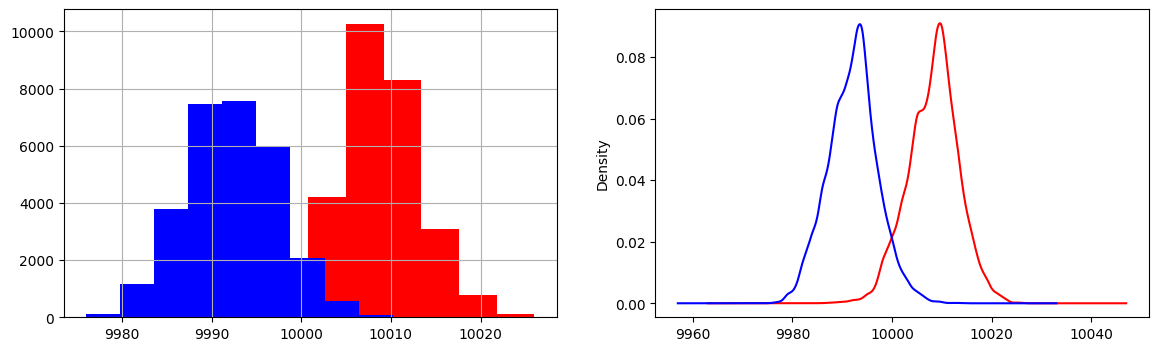

In [78]:
asks1 = df_aco["ask_price_1"]
bids1 = df_aco["bid_price_1"]

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
asks1.hist(ax=ax[0], color='red')
bids1.hist(ax=ax[0], color='blue')

asks1.plot.density(ax=ax[1], color='red')
bids1.plot.density(ax=ax[1], color='blue')

plt.show()